# Model Building, Training & Optimization

### 🎯 Goal of This Notebook
<pre>
The goal of this notebook is to design, compile, train, and optimize a deep learning model
capable of accurately classifying crop leaf images into disease or healthy categories using Keras and TensorFlow.
</pre>
### This notebook ensures:
 - Correct model architecture selection
 - Stable training on low-resource systems
 - Overfitting control
 - Best model preservation for evaluation and deployment



## Clone Repository & Set Project Root
### 📌 Purpose
<pre>
 - To obtain the complete project structure locally for exploration and experimentation.
</pre>


In [6]:

# Clone the Repository
!git clone https://github.com/sabin74/Agriculture-Crop-Disease-Detection-Advisory-System.git



fatal: destination path 'Agriculture-Crop-Disease-Detection-Advisory-System' already exists and is not an empty directory.


In [7]:
# Set Project Root
import os
os.chdir("/kaggle/working/Agriculture-Crop-Disease-Detection-Advisory-System")
print("Current Directory: ", os.getcwd())

Current Directory:  /kaggle/working/Agriculture-Crop-Disease-Detection-Advisory-System


## Import Required Libraries
###📌 Purpose

Load all libraries required for:

 - Model architecture construction
 - Training and optimization
 - Callback handling
 - Performance visualization

In [8]:
# Core Libraries
import os
import sys
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

# Data Handling
import numpy as np
import pandas as pd

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam

# Training Callbacks
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau,
    CSVLogger
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
import json
import pickle
import yaml
from datetime import datetime

# Set Visualization Style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12

print(" All libraries imported successfully!")


2026-01-29 15:34:19.790814: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769700860.043515      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769700860.113343      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769700860.661855      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769700860.661905      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769700860.661908      55 computation_placer.cc:177] computation placer alr

 All libraries imported successfully!


In [9]:
# Environment Verification
print(f" TensorFlow Version: {tf.__version__}")
print(f" Keras Version: {keras.__version__}")

# Check GPU
if tf.config.list_physical_devices('GPU'):
    print("GPU is available")
    gpus = tf.config.experimental.list_physical_devices('GPU')
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print(" GPU not available, using CPU")

 TensorFlow Version: 2.19.0
 Keras Version: 3.10.0
GPU is available


## Load Configuration & Path
### 📌 Purpose

Prepare the execution environment and confirm all preprocessing outputs required for model training are available.

In [10]:
print("LOADING CONFIGURATION...")

# Load paths from Notebook 2
CONFIG_DIR = Path("Modeling/configs")
CONFIG_PATH = CONFIG_DIR / "preprocessing_config.json"

if CONFIG_PATH.exists():
    with open(CONFIG_PATH, 'r') as f:
        config = json.load(f)
    print("Configuration loaded successfully!")
else:
    print("Configuration not found. Please run Notebook 2 first.")
    exit()



LOADING CONFIGURATION...
Configuration loaded successfully!


In [11]:
# Extract parameters
IMAGE_SIZE = tuple(config['image_parameters']['image_size'])
BATCH_SIZE = config['image_parameters']['batch_size']
TRAIN_DIR = Path(config['paths']['train_dir'])
VALID_DIR = Path(config['paths']['val_dir'])

print("\nCONFIGURATION PARAMETERS:")
print(f"  Image Size: {IMAGE_SIZE}")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Train Directory: {TRAIN_DIR}")
print(f"  Validation Directory: {VALID_DIR}")


CONFIGURATION PARAMETERS:
  Image Size: (224, 224)
  Batch Size: 32
  Train Directory: Modeling/Crop Disease Dataset/train
  Validation Directory: Modeling/Crop Disease Dataset/valid


## Load Data Generators for DISEASE Classification
**Purpose**:

Create efficient data pipelines that load images for disease classification.

In [12]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("LOADING DATA GENERATORS...")

# Load class weights (from Notebook 2)
CLASS_WEIGHTS_PATH = CONFIG_DIR / "class_weights.json"
if CLASS_WEIGHTS_PATH.exists():
    with open(CLASS_WEIGHTS_PATH, 'r') as f:
        class_weight_dict = json.load(f)
    print(f"Class weights loaded for {len(class_weight_dict)} classes")
else:
    print("Class weights not found, using equal weights")
    class_weight_dict = None


LOADING DATA GENERATORS...
Class weights loaded for 45 classes


In [13]:
# Create data generators (same as Notebook 2)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.9, 1.1],
    fill_mode='nearest'
)

valid_datagen = ImageDataGenerator(rescale=1./255)

In [14]:
# Load generators
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

val_generator = valid_datagen.flow_from_directory(
    VALID_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=42
)


Found 74880 images belonging to 45 classes.
Found 19804 images belonging to 45 classes.


In [15]:
print(f"\nDATA GENERATORS LOADED:")
print(f"  Training Images: {train_generator.samples:,}")
print(f"  Validation Images: {val_generator.samples:,}")
print(f"  Total Classes: {train_generator.num_classes}")



DATA GENERATORS LOADED:
  Training Images: 74,880
  Validation Images: 19,804
  Total Classes: 45


In [16]:
# Save class indices
class_indices = train_generator.class_indices
with open(CONFIG_DIR / "class_indices_final.json", 'w') as f:
    json.dump(class_indices, f, indent=4)
print(f"Class indices saved")

Class indices saved


## Build Model Architecture
### 📌 Purpose

Select an appropriate model architecture strategy that balances:

 - Accuracy
 - Training stability
 - Hardware limitations

This decision directly impacts training time, memory usage, and final performance.

In [17]:
print("🏗️ BUILDING MODEL ARCHITECTURE...")

NUM_CLASSES = train_generator.num_classes

# Option 1: Transfer Learning with MobileNetV2 (Recommended)
print("Using MobileNetV2 (Transfer Learning)")

# Load pretrained MobileNetV2
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=IMAGE_SIZE + (3,)
)

# Freeze base model initially
base_model.trainable = False


🏗️ BUILDING MODEL ARCHITECTURE...
Using MobileNetV2 (Transfer Learning)


I0000 00:00:1769700879.410284      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1769700879.414698      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## Build Custom Classification Head
### 📌 Purpose

Adapt the pretrained MobileNetV2 feature extractor to your crop disease dataset by adding a custom classifier head.

In [18]:
# Build custom classification head
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)  # Add dropout for regularization
x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)


In [19]:
# Create model
model = models.Model(
    inputs=base_model.input,
    outputs=outputs,
    name="CropDisease_Model"
)

print(f" Model built successfully!")
print(f"  Input Shape: {model.input_shape}")
print(f"  Output Shape: {model.output_shape}")
print(f"  Total Parameters: {model.count_params():,}")
print(f"  Trainable Parameters: {sum([w.shape.num_elements() for w in model.trainable_weights]):,}")


 Model built successfully!
  Input Shape: (None, 224, 224, 3)
  Output Shape: (None, 45)
  Total Parameters: 3,056,749
  Trainable Parameters: 798,765


In [20]:
# Save model architecture
MODELS_DIR = Path("Modeling/models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

model.summary()

Model: "CropDisease_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 3,056,749 (11.66 MB)

 Trainable params: 798,765 (3.05 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Compile the Model
### 📌 Purpose

Configure how the model learns, optimizes, and evaluates during training.

In [21]:
print("COMPILING MODEL...")

# Custom metrics for better evaluation
def f1_score(y_true, y_pred):
    """
    Custom F1-score metric for multi-class classification
    """
    # Calculate precision and recall
    true_positives = tf.keras.backend.sum(tf.keras.backend.round(tf.keras.backend.clip(y_true * y_pred, 0, 1)))
    predicted_positives = tf.keras.backend.sum(tf.keras.backend.round(tf.keras.backend.clip(y_pred, 0, 1)))
    actual_positives = tf.keras.backend.sum(tf.keras.backend.round(tf.keras.backend.clip(y_true, 0, 1)))

    precision = true_positives / (predicted_positives + tf.keras.backend.epsilon())
    recall = true_positives / (actual_positives + tf.keras.backend.epsilon())

    f1 = 2 * ((precision * recall) / (precision + recall + tf.keras.backend.epsilon()))
    return f1

# Compile model with multiple metrics
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy', f1_score]
)

print("Model compiled successfully!")
print("  Optimizer: Adam (lr=0.0001)")
print("  Loss: Categorical Crossentropy")
print("  Metrics: Accuracy, F1-Score")

COMPILING MODEL...
Model compiled successfully!
  Optimizer: Adam (lr=0.0001)
  Loss: Categorical Crossentropy
  Metrics: Accuracy, F1-Score


## Define Training Callbacks
### 📌 Purpose

Improve training stability, prevent overfitting, and automatically save the best-performing model during training.

In [22]:
print("SETTING UP TRAINING CALLBACKS...")

# Create callbacks directory
CALLBACKS_DIR = MODELS_DIR / "callbacks"
CALLBACKS_DIR.mkdir(parents=True, exist_ok=True)

# 1. Model Checkpoint - Save best model
checkpoint = ModelCheckpoint(
    filepath=MODELS_DIR / "best_model.keras",
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=False,
    mode='min',
    verbose=1
)

# 2. Early Stopping - Prevent overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# 3. Reduce Learning Rate on Plateau
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

# 4. CSV Logger - Save training history
csv_logger = CSVLogger(
    filename=CALLBACKS_DIR / "training_history.csv",
    separator=',',
    append=False
)

# Combine all callbacks
callbacks = [checkpoint, early_stop, reduce_lr, csv_logger]

print("Callbacks configured!")
print(f"  Best model will be saved to: {MODELS_DIR / 'best_model.keras'}")
print(f"  Training history: {CALLBACKS_DIR / 'training_history.csv'}")

SETTING UP TRAINING CALLBACKS...
Callbacks configured!
  Best model will be saved to: Modeling/models/best_model.keras
  Training history: Modeling/models/callbacks/training_history.csv


## 🏋️‍♂️ Phase 1: Train Classification Head (Frozen Base)
**Purpose**:

 Train only the custom classification head while keeping the pretrained MobileNetV2 base model frozen. This helps the model learn disease-specific patterns.

In [23]:
print("STARTING PHASE 1 TRAINING...")
print("Training only the custom classification head (base model frozen)")

# Calculate steps
steps_per_epoch = train_generator.samples // BATCH_SIZE
validation_steps = val_generator.samples // BATCH_SIZE

# Training parameters
EPOCHS_PHASE1 = 20

print(f"\nTRAINING PARAMETERS - PHASE 1:")
print(f"  Epochs: {EPOCHS_PHASE1}")
print(f"  Steps per epoch: {steps_per_epoch}")
print(f"  Validation steps: {validation_steps}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Class weights: {'Applied' if class_weight_dict else 'Not applied'}")

# Train the model
history_phase1 = model.fit(
    train_generator,
    epochs=EPOCHS_PHASE1,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_generator,
    validation_steps=validation_steps,
    callbacks=callbacks,
    class_weight=class_weight_dict,  # Handle class imbalance
    verbose=1
)

print("Phase 1 training completed!")
print(f"  Final Training Accuracy: {history_phase1.history['accuracy'][-1]:.4f}")
print(f"  Final Validation Accuracy: {history_phase1.history['val_accuracy'][-1]:.4f}")
print(f"  Final Training Loss: {history_phase1.history['loss'][-1]:.4f}")
print(f"  Final Validation Loss: {history_phase1.history['val_loss'][-1]:.4f}")

STARTING PHASE 1 TRAINING...
Training only the custom classification head (base model frozen)

TRAINING PARAMETERS - PHASE 1:
  Epochs: 20
  Steps per epoch: 2340
  Validation steps: 618
  Batch size: 32
  Class weights: Applied
Epoch 1/20


I0000 00:00:1769700888.451309     160 service.cc:152] XLA service 0x7a603810ff90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1769700888.451347     160 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1769700888.451354     160 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1769700889.586360     160 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-01-29 15:34:58.332179: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-29 15:34:58.493368: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-29 15:34:58.629919: E external/local_xl

2340/2340 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.4641 - f1_score: 0.3758 - loss: 1.9909
Epoch 1: val_loss improved from inf to 0.48446, saving model to Modeling/models/best_model.keras
2340/2340 ━━━━━━━━━━━━━━━━━━━━ 944s 395ms/step - accuracy: 0.4642 - f1_score: 0.3759 - loss: 1.9905 - val_accuracy: 0.8479 - val_f1_score: 0.8287 - val_loss: 0.4845 - learning_rate: 1.0000e-04
Epoch 2/20
2340/2340 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - accuracy: 0.7972 - f1_score: 0.7949 - loss: 0.6173
Epoch 2: val_loss improved from 0.48446 to 0.37633, saving model to Modeling/models/best_model.keras
2340/2340 ━━━━━━━━━━━━━━━━━━━━ 882s 377ms/step - accuracy: 0.7972 - f1_score: 0.7949 - loss: 0.6172 - val_accuracy: 0.8794 - val_f1_score: 0.8726 - val_loss: 0.3763 - learning_rate: 1.0000e-04
Epoch 3/20
2340/2340 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step - accuracy: 0.8414 - f1_score: 0.8406 - loss: 0.4777
Epoch 3: val_loss improved from 0.37633 to 0.33039, saving model to Modeling/models/best_model.keras

## 🎯 Phase 2: Fine-Tuning for Better Disease Recognition
**Purpose**:

Improve model accuracy by fine-tuning higher-level features of the pretrained MobileNetV2 base model for specific disease patterns.

In [24]:
print("STARTING PHASE 2: FINE-TUNING...")
print("Unfreezing some base model layers for better feature extraction")

# Unfreeze last 50 layers of base model
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

# Recompile with lower learning rate
model.compile(
    optimizer=Adam(learning_rate=0.00001),  # Lower learning rate
    loss='categorical_crossentropy',
    metrics=['accuracy', f1_score]
)

print("Base model partially unfrozen")
print(f"  Trainable layers: {sum([layer.trainable for layer in model.layers])}")
print(f"  Total layers: {len(model.layers)}")
print(f"  New learning rate: 0.00001")

# Fine-tuning parameters
EPOCHS_PHASE2 = 20
total_epochs = EPOCHS_PHASE1 + EPOCHS_PHASE2

print(f"\nFINE-TUNING PARAMETERS:")
print(f"  Additional epochs: {EPOCHS_PHASE2}")
print(f"  Total epochs: {total_epochs}")

# Continue training
history_phase2 = model.fit(
    train_generator,
    epochs=total_epochs,
    initial_epoch=history_phase1.epoch[-1],
    steps_per_epoch=steps_per_epoch,
    validation_data=val_generator,
    validation_steps=validation_steps,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

print("Fine-tuning completed!")
print(f"  Final Training Accuracy: {history_phase2.history['accuracy'][-1]:.4f}")
print(f"  Final Validation Accuracy: {history_phase2.history['val_accuracy'][-1]:.4f}")
print(f"  Improvement from Phase 1: {history_phase2.history['val_accuracy'][-1] - history_phase1.history['val_accuracy'][-1]:.4f}")

STARTING PHASE 2: FINE-TUNING...
Unfreezing some base model layers for better feature extraction
Base model partially unfrozen
  Trainable layers: 57
  Total layers: 161
  New learning rate: 0.00001

FINE-TUNING PARAMETERS:
  Additional epochs: 20
  Total epochs: 40
Epoch 20/40
2340/2340 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.7837 - f1_score: 0.7847 - loss: 0.7530
Epoch 20: val_loss did not improve from 0.21651
2340/2340 ━━━━━━━━━━━━━━━━━━━━ 917s 383ms/step - accuracy: 0.7837 - f1_score: 0.7847 - loss: 0.7529 - val_accuracy: 0.9291 - val_f1_score: 0.9282 - val_loss: 0.2446 - learning_rate: 1.0000e-05
Epoch 21/40
2340/2340 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.9121 - f1_score: 0.9124 - loss: 0.2554
Epoch 21: val_loss improved from 0.21651 to 0.20355, saving model to Modeling/models/best_model.keras
2340/2340 ━━━━━━━━━━━━━━━━━━━━ 895s 382ms/step - accuracy: 0.9122 - f1_score: 0.9124 - loss: 0.2554 - val_accuracy: 0.9437 - val_f1_score: 0.9429 - val_loss: 0.2035 - lea

# Save Final Model
**Purpose**:

Preserve the model after training for disease classification.

In [25]:
print("SAVING FINAL MODEL...")

# Save final model
final_model_path = MODELS_DIR / "final_model.keras"
model.save(final_model_path)
print(f"Final model saved: {final_model_path}")

# Save in H5 format for compatibility
h5_model_path = MODELS_DIR / "final_model.h5"
model.save(h5_model_path)
print(f"Model saved (H5): {h5_model_path}")


SAVING FINAL MODEL...


Final model saved: Modeling/models/final_model.keras
Model saved (H5): Modeling/models/final_model.h5


In [26]:
# Combine and save training history
complete_history = {
    'accuracy': history_phase1.history['accuracy'] + history_phase2.history['accuracy'],
    'val_accuracy': history_phase1.history['val_accuracy'] + history_phase2.history['val_accuracy'],
    'loss': history_phase1.history['loss'] + history_phase2.history['loss'],
    'val_loss': history_phase1.history['val_loss'] + history_phase2.history['val_loss'],
    'f1_score': history_phase1.history['f1_score'] + history_phase2.history['f1_score'],
    'val_f1_score': history_phase1.history['val_f1_score'] + history_phase2.history['val_f1_score']
}

with open(MODELS_DIR / "complete_history.pkl", 'wb') as f:
    pickle.dump(complete_history, f)
print(f"Training history saved: {MODELS_DIR / 'complete_history.pkl'}")


Training history saved: Modeling/models/complete_history.pkl


In [27]:
# Save as JSON for easy reading
history_json = {
    'training_accuracy': [float(x) for x in complete_history['accuracy']],
    'validation_accuracy': [float(x) for x in complete_history['val_accuracy']],
    'training_loss': [float(x) for x in complete_history['loss']],
    'validation_loss': [float(x) for x in complete_history['val_loss']],
    'training_f1': [float(x) for x in complete_history['f1_score']],
    'validation_f1': [float(x) for x in complete_history['val_f1_score']]
}

with open(MODELS_DIR / "training_history.json", 'w') as f:
    json.dump(history_json, f, indent=4)
print(f"Training history (JSON): {MODELS_DIR / 'training_history.json'}")

Training history (JSON): Modeling/models/training_history.json


# Visualize Training Result
**Purpose**

Plot Accuracy and Loss Curve

VISUALIZING TRAINING RESULTS...


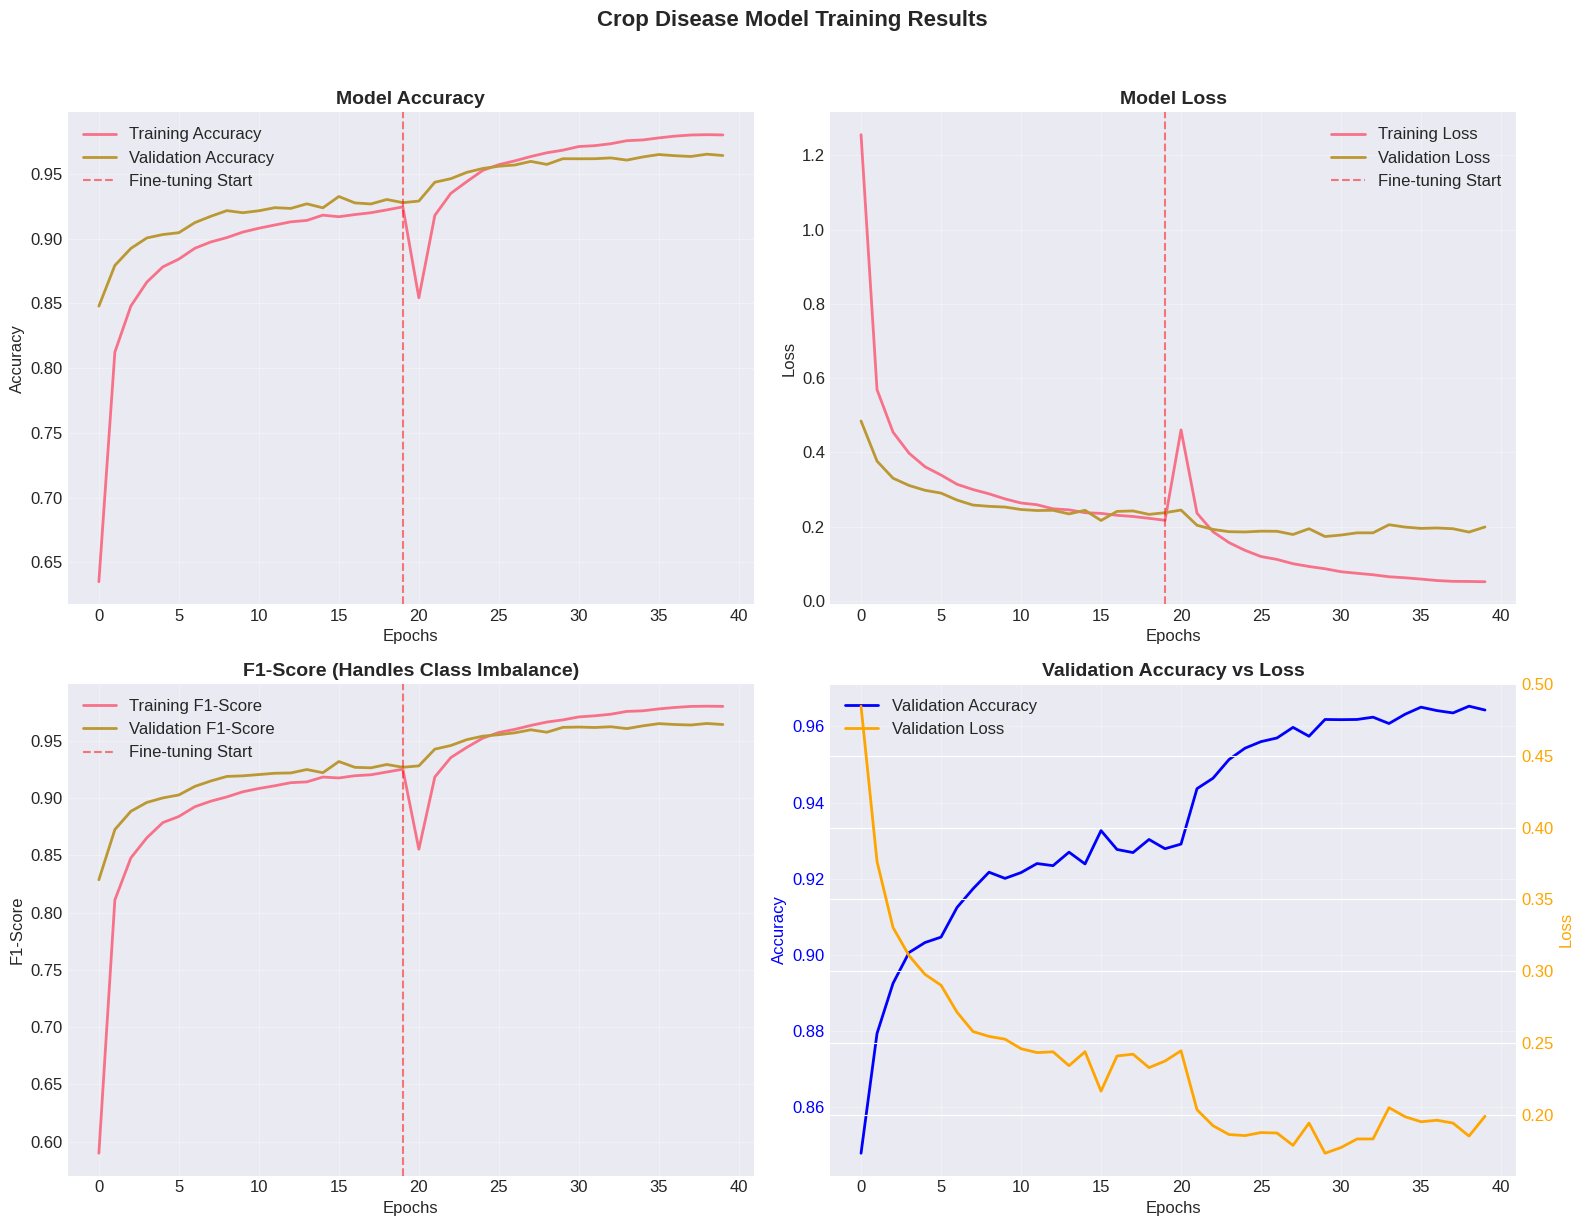

Training plots saved to: Modeling/reports/figures/training/training_results.png


In [28]:
print("VISUALIZING TRAINING RESULTS...")

# Create visualization directory
VIZ_DIR = Path("Modeling/reports/figures/training")
VIZ_DIR.mkdir(parents=True, exist_ok=True)

# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Accuracy Plot
axes[0, 0].plot(complete_history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0, 0].plot(complete_history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0, 0].axvline(x=EPOCHS_PHASE1-1, color='red', linestyle='--', alpha=0.5, label='Fine-tuning Start')
axes[0, 0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epochs')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Loss Plot
axes[0, 1].plot(complete_history['loss'], label='Training Loss', linewidth=2)
axes[0, 1].plot(complete_history['val_loss'], label='Validation Loss', linewidth=2)
axes[0, 1].axvline(x=EPOCHS_PHASE1-1, color='red', linestyle='--', alpha=0.5, label='Fine-tuning Start')
axes[0, 1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epochs')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. F1-Score Plot
axes[1, 0].plot(complete_history['f1_score'], label='Training F1-Score', linewidth=2)
axes[1, 0].plot(complete_history['val_f1_score'], label='Validation F1-Score', linewidth=2)
axes[1, 0].axvline(x=EPOCHS_PHASE1-1, color='red', linestyle='--', alpha=0.5, label='Fine-tuning Start')
axes[1, 0].set_title('F1-Score (Handles Class Imbalance)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Epochs')
axes[1, 0].set_ylabel('F1-Score')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Accuracy-Loss Comparison
ax2 = axes[1, 1].twinx()
lns1 = axes[1, 1].plot(complete_history['val_accuracy'], label='Validation Accuracy', color='blue', linewidth=2)
lns2 = ax2.plot(complete_history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
axes[1, 1].set_title('Validation Accuracy vs Loss', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Epochs')
axes[1, 1].set_ylabel('Accuracy', color='blue')
ax2.set_ylabel('Loss', color='orange')
axes[1, 1].tick_params(axis='y', labelcolor='blue')
ax2.tick_params(axis='y', labelcolor='orange')

# Combine legends
lns = lns1 + lns2
labs = [l.get_label() for l in lns]
axes[1, 1].legend(lns, labs, loc='best')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Crop Disease Model Training Results', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(VIZ_DIR / "training_results.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Training plots saved to: {VIZ_DIR / 'training_results.png'}")

# Model Qvaluation

In [29]:
print("🧪 EVALUATING MODEL PERFORMANCE...")

# Evaluate on validation set
val_loss, val_accuracy, val_f1 = model.evaluate(val_generator, verbose=0)

print(f"\nVALIDATION SET PERFORMANCE:")
print(f"  Loss: {val_loss:.4f}")
print(f"  Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
print(f"  F1-Score: {val_f1:.4f}")

# Check for overfitting
train_loss = complete_history['loss'][-1]
train_accuracy = complete_history['accuracy'][-1]
overfitting_gap = train_accuracy - val_accuracy

print(f"\nOVERFITTING ANALYSIS:")
print(f"  Training Accuracy: {train_accuracy:.4f}")
print(f"  Validation Accuracy: {val_accuracy:.4f}")
print(f"  Accuracy Gap: {overfitting_gap:.4f}")

if overfitting_gap > 0.1:
    print(f"  Warning: Significant overfitting detected")
elif overfitting_gap > 0.05:
    print(f"  Moderate overfitting detected")
else:
    print(f" Good generalization - minimal overfitting")

# Save evaluation results - FIXED: Convert numpy types to Python native types
evaluation_results = {
    'validation_loss': float(val_loss),
    'validation_accuracy': float(val_accuracy),
    'validation_f1_score': float(val_f1),
    'training_accuracy': float(train_accuracy),
    'overfitting_gap': float(overfitting_gap),
    'total_epochs': int(len(complete_history['accuracy'])),
    'best_epoch': int(np.argmin(complete_history['val_loss'])) + 1,  # Convert to int
    'best_validation_loss': float(np.min(complete_history['val_loss'])),
    'best_validation_accuracy': float(np.max(complete_history['val_accuracy']))
}

# Alternative: Use custom JSON encoder for numpy types
import json
import numpy as np

class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, (np.integer, np.int32, np.int64, np.int8, np.int16)):
            return int(obj)
        elif isinstance(obj, (np.floating, np.float32, np.float64, np.float16)):
            return float(obj)
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        elif isinstance(obj, np.bool_):
            return bool(obj)
        else:
            return super().default(obj)

# Save with custom encoder
with open(MODELS_DIR / "evaluation_results.json", 'w') as f:
    json.dump(evaluation_results, f, indent=4, cls=NumpyEncoder)

print(f"\nEvaluation results saved to: {MODELS_DIR / 'evaluation_results.json'}")

🧪 EVALUATING MODEL PERFORMANCE...


2026-01-30 01:27:11.493214: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-30 01:27:11.631585: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-30 01:27:11.765646: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



VALIDATION SET PERFORMANCE:
  Loss: 0.1730
  Accuracy: 0.9619 (96.19%)
  F1-Score: 0.9619

OVERFITTING ANALYSIS:
  Training Accuracy: 0.9802
  Validation Accuracy: 0.9619
  Accuracy Gap: 0.0183
 Good generalization - minimal overfitting

Evaluation results saved to: Modeling/models/evaluation_results.json


# Quick Test on Sample Images

In [30]:
print("QUICK TEST ON SAMPLE IMAGES...")

# Load class names mapping
with open(CONFIG_DIR / "class_indices_final.json", 'r') as f:
    class_indices = json.load(f)

# Create reverse mapping
idx_to_class = {v: k for k, v in class_indices.items()}

# Get a batch of validation images
sample_images, sample_labels = next(val_generator)

# Predict
predictions = model.predict(sample_images[:5], verbose=0)

print(f"\nSample Predictions (5 images):")
print("-" * 50)

for i in range(5):
    true_idx = np.argmax(sample_labels[i])
    true_class = idx_to_class[true_idx]

    pred_idx = np.argmax(predictions[i])
    pred_class = idx_to_class[pred_idx]
    confidence = predictions[i][pred_idx] * 100

    print(f"\nImage {i+1}:")
    print(f"  True: {true_class}")
    print(f"  Predicted: {pred_class}")
    print(f"  Confidence: {confidence:.1f}%")
    print(f"  Result: {'✓ CORRECT' if true_idx == pred_idx else '✗ WRONG'}")

accuracy_test = sum([np.argmax(sample_labels[i]) == np.argmax(predictions[i]) for i in range(5)]) / 5
print(f"\nSample Test Accuracy: {accuracy_test*100:.0f}%")

QUICK TEST ON SAMPLE IMAGES...


2026-01-30 01:27:21.845859: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-30 01:27:21.996696: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-30 01:27:22.132208: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Sample Predictions (5 images):
--------------------------------------------------

Image 1:
  True: Apple__Apple_scab
  Predicted: Apple__Apple_scab
  Confidence: 100.0%
  Result: ✓ CORRECT

Image 2:
  True: Apple__Apple_scab
  Predicted: Apple__Apple_scab
  Confidence: 100.0%
  Result: ✓ CORRECT

Image 3:
  True: Apple__Apple_scab
  Predicted: Apple__Apple_scab
  Confidence: 100.0%
  Result: ✓ CORRECT

Image 4:
  True: Apple__Apple_scab
  Predicted: Apple__Apple_scab
  Confidence: 100.0%
  Result: ✓ CORRECT

Image 5:
  True: Apple__Apple_scab
  Predicted: Apple__Apple_scab
  Confidence: 95.4%
  Result: ✓ CORRECT

Sample Test Accuracy: 100%


# Final Summary


In [31]:
print("MODEL TRAINING COMPLETED SUCCESSFULLY!")

print(f"\nFINAL RESULTS:")
print(f"  Total Epochs Trained: {len(complete_history['accuracy'])}")
print(f"  Best Validation Accuracy: {evaluation_results['best_validation_accuracy']:.2%}")
print(f"  Best Validation Loss: {evaluation_results['best_validation_loss']:.4f}")
print(f"  Final Validation Accuracy: {evaluation_results['validation_accuracy']:.2%}")
print(f"  Final F1-Score: {evaluation_results['validation_f1_score']:.4f}")
print(f"  Overfitting Gap: {evaluation_results['overfitting_gap']:.4f}")

print(f"\nKEY FEATURES IMPLEMENTED:")
print(f"  1. Transfer Learning with MobileNetV2")
print(f"  2. Class weighting for imbalanced data")
print(f"  3. Dropout layers for regularization")
print(f"  4. Early stopping to prevent overfitting")
print(f"  5. Learning rate scheduling")
print(f"  6. Two-phase training (frozen + fine-tuning)")
print(f"  7. F1-score metric for better evaluation")

print(f"\nSAVED FILES:")
print(f"  - best_model.keras - Best performing model")
print(f"  - final_model.keras - Final trained model")
print(f"  - training_results.png - Training visualization")
print(f"  - evaluation_results.json - Performance metrics")
print(f"  - class_indices_final.json - Class name mapping")

print(f"\nNEXT STEPS:")
print(f"  1. Proceed to '04_model_evaluation.ipynb' for detailed testing")
print(f"  2. Use the model for inference in '05_inference_demo.ipynb'")
print(f"  3. Check the downloaded zip file for all model files")

print(f"\nTIPS FOR BETTER PERFORMANCE:")
print(f"  - If accuracy is low, increase training epochs")
print(f"  - For overfitting, increase dropout rates")
print(f"  - For slow training, reduce image size or batch size")
print(f"  - For memory issues, use smaller batch size")

print(f"\nREADY FOR EVALUATION AND DEPLOYMENT!")

MODEL TRAINING COMPLETED SUCCESSFULLY!

FINAL RESULTS:
  Total Epochs Trained: 40
  Best Validation Accuracy: 96.53%
  Best Validation Loss: 0.1733
  Final Validation Accuracy: 96.19%
  Final F1-Score: 0.9619
  Overfitting Gap: 0.0183

KEY FEATURES IMPLEMENTED:
  1. Transfer Learning with MobileNetV2
  2. Class weighting for imbalanced data
  3. Dropout layers for regularization
  4. Early stopping to prevent overfitting
  5. Learning rate scheduling
  6. Two-phase training (frozen + fine-tuning)
  7. F1-score metric for better evaluation

SAVED FILES:
  - best_model.keras - Best performing model
  - final_model.keras - Final trained model
  - training_results.png - Training visualization
  - evaluation_results.json - Performance metrics
  - class_indices_final.json - Class name mapping

NEXT STEPS:
  1. Proceed to '04_model_evaluation.ipynb' for detailed testing
  2. Use the model for inference in '05_inference_demo.ipynb'
  3. Check the downloaded zip file for all model files

TIPS F